# R5 — Exploración de noticias crudas (MediaCloud)

Inspecciona los parquets descargados antes de clasificar sentimiento.  
Objetivos:
- Verificar cobertura temporal por empresa
- Revisar campos disponibles (título, texto, fecha, fuente)
- Detectar problemas de calidad (nulos, duplicados, ruido)

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path("..")
sys.path.insert(0, str(ROOT))

RAW_DIR = ROOT / "data" / "raw"

TICKERS = ["CREDITC1", "BUENAVC1", "ALICORC1", "SAGAC1", "CORAREC1"]
TICKER_NAMES = {
    "CREDITC1": "BCP / Credicorp",
    "BUENAVC1": "Buenaventura",
    "ALICORC1": "Alicorp",
    "SAGAC1":   "Saga Falabella",
    "CORAREC1": "Aceros Arequipa",
}

## 1. Carga de parquets

In [2]:
frames = {}
for ticker in TICKERS:
    path = RAW_DIR / f"news_{ticker}.parquet"
    if path.exists():
        frames[ticker] = pd.read_parquet(path)
        print(f"{ticker:12} {len(frames[ticker]):>6} noticias  — columnas: {list(frames[ticker].columns)}")
    else:
        print(f"{ticker:12} SIN ARCHIVO ({path.name})")

CREDITC1       7933 noticias  — columnas: ['id', 'indexed_date', 'language', 'media_name', 'media_url', 'publish_date', 'title', 'url', 'ticker']
BUENAVC1        978 noticias  — columnas: ['id', 'indexed_date', 'language', 'media_name', 'media_url', 'publish_date', 'title', 'url', 'ticker']
ALICORC1       1585 noticias  — columnas: ['id', 'indexed_date', 'language', 'media_name', 'media_url', 'publish_date', 'title', 'url', 'ticker']
SAGAC1          380 noticias  — columnas: ['id', 'indexed_date', 'language', 'media_name', 'media_url', 'publish_date', 'title', 'url', 'ticker']
CORAREC1        690 noticias  — columnas: ['id', 'indexed_date', 'language', 'media_name', 'media_url', 'publish_date', 'title', 'url', 'ticker']


## 2. Resumen por empresa

In [3]:
summary_rows = []
for ticker, df in frames.items():
    date_col = next((c for c in ["publish_date", "date", "published_at"] if c in df.columns), None)
    if date_col:
        df["_date"] = pd.to_datetime(df[date_col], errors="coerce")
        min_d, max_d = df["_date"].min(), df["_date"].max()
    else:
        min_d = max_d = pd.NaT

    title_col = next((c for c in ["title", "headline"] if c in df.columns), None)
    text_col  = next((c for c in ["text", "story_text", "content"] if c in df.columns), None)

    summary_rows.append({
        "ticker": ticker,
        "nombre": TICKER_NAMES[ticker],
        "total": len(df),
        "fecha_min": min_d.date() if pd.notna(min_d) else None,
        "fecha_max": max_d.date() if pd.notna(max_d) else None,
        "nulos_titulo": df[title_col].isna().sum() if title_col else "N/A",
        "nulos_texto":  df[text_col].isna().sum()  if text_col  else "N/A",
        "duplicados_url": df["url"].duplicated().sum() if "url" in df.columns else "N/A",
    })

summary = pd.DataFrame(summary_rows).set_index("ticker")
summary

,nombre,total,fecha_min,fecha_max,nulos_titulo,nulos_texto,duplicados_url
ticker,,,,,,,
CREDITC1,BCP / Credicorp,7933,2013-03-27,2025-12-31,0,N/A,0
BUENAVC1,Buenaventura,978,2013-03-18,2025-12-24,0,N/A,0
ALICORC1,Alicorp,1585,2013-02-08,2025-12-31,0,N/A,0
SAGAC1,Saga Falabella,380,2013-04-01,2025-12-29,0,N/A,0
CORAREC1,Aceros Arequipa,690,2013-08-09,2025-12-29,0,N/A,0


## 3. Columnas disponibles y tipos

In [4]:
# Usar el primer DataFrame disponible como referencia
sample_ticker = next(iter(frames))
df_sample = frames[sample_ticker]
print(f"Referencia: {sample_ticker}")
df_sample.dtypes

Referencia: CREDITC1


id                              str
indexed_date    datetime64[us, UTC]
language                        str
media_name                      str
media_url                       str
publish_date                 object
title                           str
url                             str
ticker                          str
_date                 datetime64[s]
dtype: object

## 4. Cobertura temporal — noticias por año

In [5]:
date_col = next((c for c in ["publish_date", "date", "published_at"] if c in df_sample.columns), None)

yearly = {}
for ticker, df in frames.items():
    if date_col and date_col in df.columns:
        df["_year"] = pd.to_datetime(df[date_col], errors="coerce").dt.year
        yearly[ticker] = df.groupby("_year").size()

if yearly:
    yearly_df = pd.DataFrame(yearly).fillna(0).astype(int).sort_index()
    yearly_df.index.name = "año"
    print(yearly_df.to_string())
    print(f"\nTotal por empresa:\n{yearly_df.sum().to_string()}")

      CREDITC1  BUENAVC1  ALICORC1  SAGAC1  CORAREC1
año                                                 
2013        77         9        12      10         3
2014       169        29        34      38        21
2015        88        11        23      13         1
2016       133        15        36      24         4
2017       390        35       101      28        47
2018       429        42       142      44        34
2019       242        32       113      33        16
2020       334        30        82      28        35
2021       949       107       232      37       140
2022      1209       269       196      47       165
2023      1376       240       250      27       132
2024      1390        99       189      18        56
2025      1147        60       175      33        36

Total por empresa:
CREDITC1    7933
BUENAVC1     978
ALICORC1    1585
SAGAC1       380
CORAREC1     690


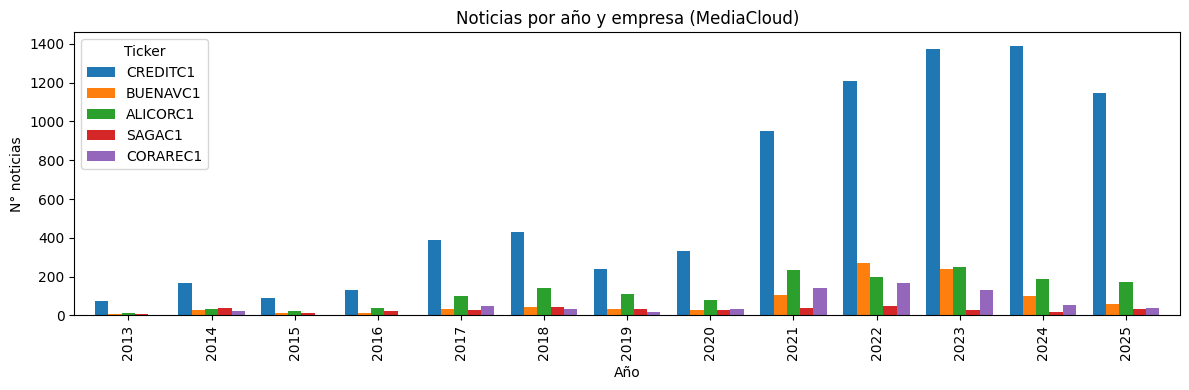

In [6]:
if yearly:
    fig, ax = plt.subplots(figsize=(12, 4))
    yearly_df.plot(kind="bar", ax=ax, width=0.8)
    ax.set_title("Noticias por año y empresa (MediaCloud)")
    ax.set_xlabel("Año")
    ax.set_ylabel("N° noticias")
    ax.legend(title="Ticker")
    plt.tight_layout()
    plt.show()

## 5. Distribución mensual (serie temporal)

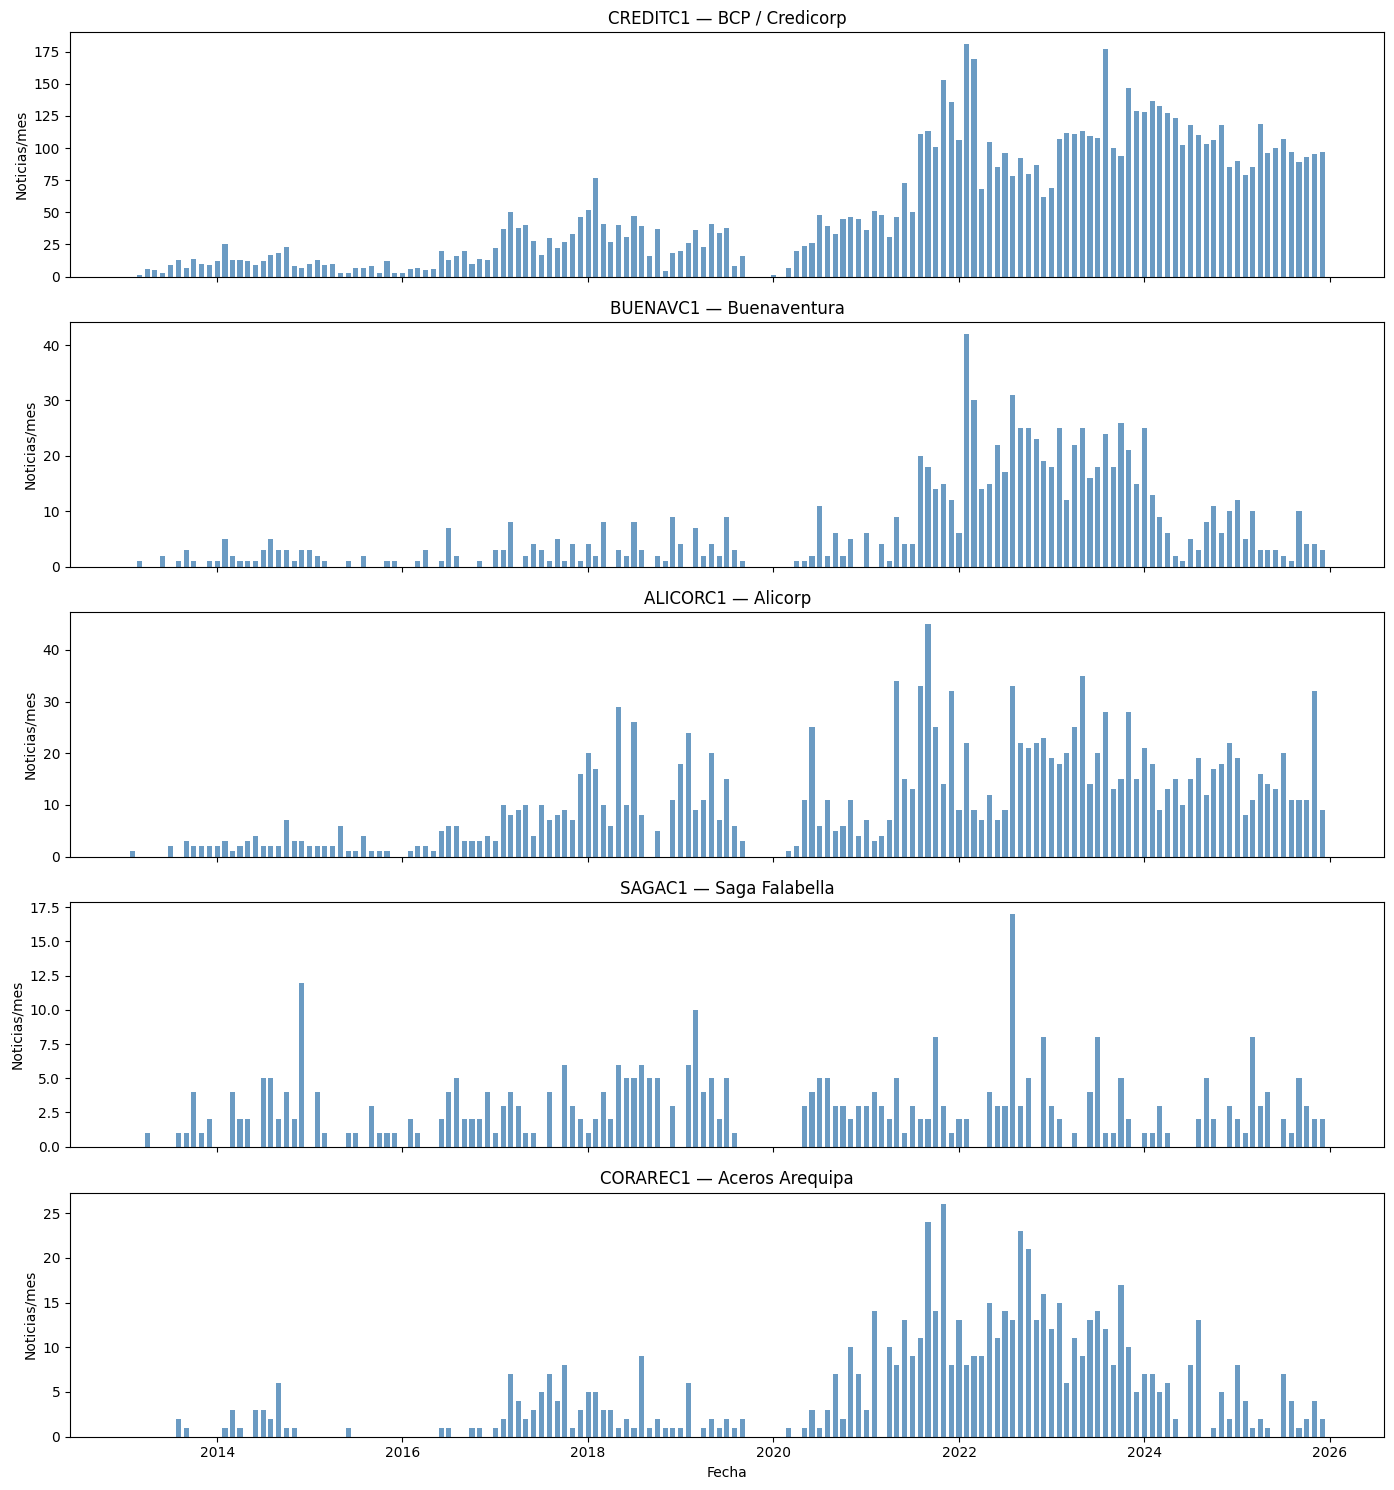

In [7]:
if date_col:
    fig, axes = plt.subplots(len(frames), 1, figsize=(14, 3 * len(frames)), sharex=True)
    if len(frames) == 1:
        axes = [axes]

    for ax, (ticker, df) in zip(axes, frames.items()):
        monthly = (pd.to_datetime(df[date_col], errors="coerce")
                     .dt.to_period("M")
                     .value_counts()
                     .sort_index())
        monthly.index = monthly.index.to_timestamp()
        ax.bar(monthly.index, monthly.values, width=20, color="steelblue", alpha=0.8)
        ax.set_title(f"{ticker} — {TICKER_NAMES[ticker]}")
        ax.set_ylabel("Noticias/mes")

    plt.xlabel("Fecha")
    plt.tight_layout()
    plt.show()

## 6. Muestra de noticias

In [8]:
title_col = next((c for c in ["title", "headline"] if c in df_sample.columns), None)
text_col  = next((c for c in ["text", "story_text", "content"] if c in df_sample.columns), None)
url_col   = "url" if "url" in df_sample.columns else None

cols_show = [c for c in [date_col, title_col, text_col, url_col, "media_name"] if c and c in df_sample.columns]

for ticker, df in frames.items():
    print(f"\n{'='*60}")
    print(f"  {ticker} — {TICKER_NAMES[ticker]}  ({len(df)} noticias)")
    print(f"{'='*60}")
    sample = df[cols_show].sample(min(3, len(df)), random_state=42)
    for _, row in sample.iterrows():
        if date_col: print(f"  Fecha : {row.get(date_col)}")
        if title_col: print(f"  Título: {str(row.get(title_col, ''))[:120]}")
        if text_col:  print(f"  Texto : {str(row.get(text_col, ''))[:200]}")
        if url_col:   print(f"  URL   : {row.get(url_col)}")
        print()


  CREDITC1 — BCP / Credicorp  (7933 noticias)
  Fecha : 2021-10-22
  Título: Bolsa de Valores de Lima inicia jornada al alza tras haber borrado todas sus pérdidas en el año
  URL   : https://gestion.pe/economia/mercados/bvl-bolsa-de-valores-de-lima-inicia-jornada-al-alza-tras-haber-borrado-todas-sus-perdidas-en-el-ano-nndc-noticia/

  Fecha : 2025-10-09
  Título: Cada 19 minutos se presenta una denuncia por extorsión en el Perú: ¿Qué regiones son las más afectadas?
  URL   : https://elcomercio.pe/peru/mas-de-20-mil-denuncias-por-extorsion-en-el-2025-lima-y-las-regiones-que-viven-al-limite-la-crisis-extorsion-dina-boluarte-transportistas-policia-nacional-paro-noticia/

  Fecha : 2021-03-11
  Título: Mercado laboral peruano seguirá afectado y más informal que niveles pre COVID-19
  URL   : https://elcomercio.pe/economia/peru/mercado-laboral-peruano-seguira-afectado-y-mas-informal-que-niveles-pre-covid-19-desempleo-pandemia-noticia/


  BUENAVC1 — Buenaventura  (978 noticias)
  Fecha : 2

## 7. Medios más frecuentes por empresa

In [9]:
media_col = next((c for c in ["media_name", "source_name", "domain"] if c in df_sample.columns), None)

if media_col:
    for ticker, df in frames.items():
        if media_col in df.columns:
            top = df[media_col].value_counts().head(10)
            print(f"\n{ticker} — top 10 medios:")
            print(top.to_string())
else:
    print("No se encontró columna de medio/fuente en los datos.")


CREDITC1 — top 10 medios:
media_name
larepublica.pe    2880
gestion.pe        2752
elcomercio.pe     2301

BUENAVC1 — top 10 medios:
media_name
gestion.pe        636
elcomercio.pe     232
larepublica.pe    110

ALICORC1 — top 10 medios:
media_name
gestion.pe        910
elcomercio.pe     486
larepublica.pe    189

SAGAC1 — top 10 medios:
media_name
gestion.pe        152
larepublica.pe    122
elcomercio.pe     106

CORAREC1 — top 10 medios:
media_name
gestion.pe        397
elcomercio.pe     206
larepublica.pe     87


## 8. Preparación para clasificación

Verifica que los campos necesarios para `classify_dataframe` estén presentes:
- `id` o `url` (clave de caché)
- `title` (entrada al prompt)
- `text` (entrada al prompt, truncado a 2 000 chars)
- `publish_date` (para `aggregate_daily`)
- `ticker` (columna añadida por `fetch_stories`)

In [10]:
REQUIRED = {
    "clave_cache":    ["id", "url"],
    "titulo":         ["title", "headline"],
    "texto":          ["text", "story_text", "content"],
    "fecha_pub":      ["publish_date", "date", "published_at"],
    "ticker":         ["ticker"],
}

print(f"{'Campo':<15} {'Columna encontrada':<22} {'Ticker de ref.'}")
print("-" * 60)
for campo, candidatos in REQUIRED.items():
    found = next((c for c in candidatos if c in df_sample.columns), None)
    status = f"✓ {found}" if found else "✗ NO ENCONTRADO"
    print(f"  {campo:<13} {status:<22} ({sample_ticker})")

print("\nNota: si 'texto' no existe, el LLM solo verá el título (cobertura parcial).")

Campo           Columna encontrada     Ticker de ref.
------------------------------------------------------------
  clave_cache   ✓ id                   (CREDITC1)
  titulo        ✓ title                (CREDITC1)
  texto         ✗ NO ENCONTRADO        (CREDITC1)
  fecha_pub     ✓ publish_date         (CREDITC1)
  ticker        ✓ ticker               (CREDITC1)

Nota: si 'texto' no existe, el LLM solo verá el título (cobertura parcial).
